<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_1_(Exercise_1_1)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Setup

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

#Loading one MNIST image
dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
x0, label = dataset[0]      # shape: (1,28,28), values in [0,1]
print(f"Label: {label}, Image Vector: {x0}")     #normalize to [-1,1] - DDPM convention (because we want at t=T The distribution converges properly to N(0,1))

100%|██████████| 9.91M/9.91M [00:00<00:00, 140MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 64.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 113MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.6MB/s]


Label: 7, Image: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000

In [4]:
# Implementing both schedules

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

def cosine_schedule(T, s=0.008):
    t = torch.arange(T + 1)
    f = torch.cos(((t / T + s) / (1 + s)) * torch.pi / 2) ** 2
    alpha_bar = f / f[0]
    alpha_bar = alpha_bar[1:]              # index 1..T → t=1..T
    betas = 1 - alpha_bar / torch.cat([alpha_bar[:1], alpha_bar[:-1]])
    betas = betas.clamp(max=0.999)
    return betas, alpha_bar

In [5]:
# Closed form forward process

def forward_process(x0, t_idx, alpha_bar):
    """
    x0: (1, H, W) tensor
    t_idx: int, 0-indexed (so t=0 means no noise, t=999 is full noise)
    """
    if t_idx == 0:
        return x0.clone()
    ab = alpha_bar[t_idx - 1]             # ᾱ_t
    eps = torch.randn_like(x0)
    x_t = (ab ** 0.5) * x0 + ((1 - ab) ** 0.5) * eps
    return x_t

In [6]:
# SNR Calculation

def snr(alpha_bar, t_idx):
    if t_idx == 0:
        return float('inf')
    ab = alpha_bar[t_idx - 1].item()
    return ab / (1 - ab)

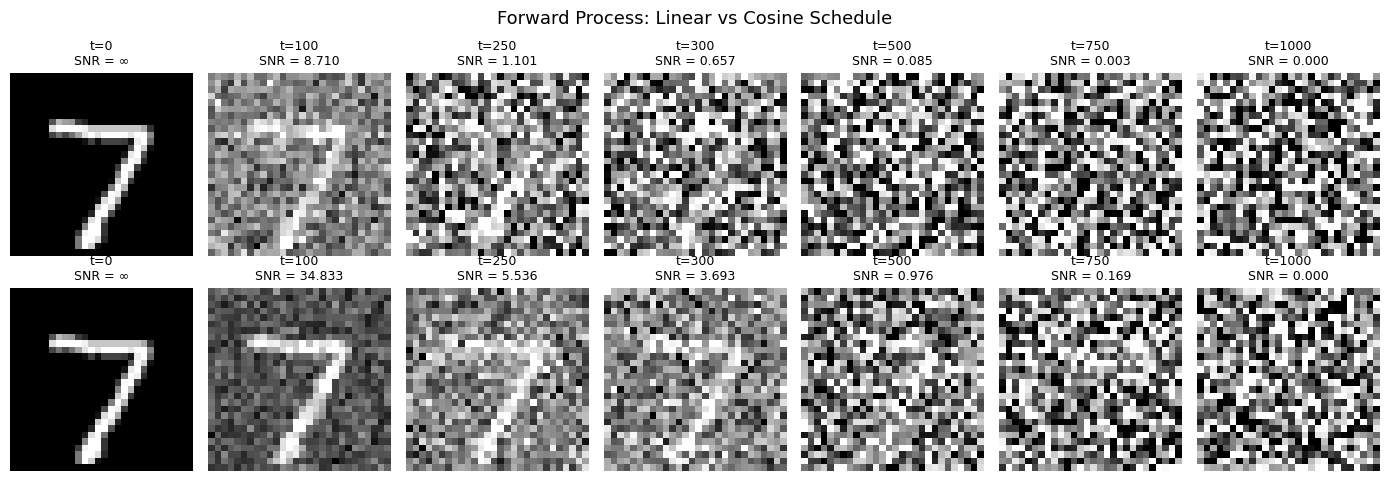

In [16]:
# Plot Both Schedules

timesteps = [0, 100, 250, 300, 500, 750, 1000] # extra 300 added to see the difference more clearly.

fig, axes = plt.subplots(2, len(timesteps), figsize=(14, 5))
schedule_names = ['Linear', 'Cosine']
schedules = [linear_schedule(T), cosine_schedule(T)]

for row, (name, (betas, alpha_bar)) in enumerate(zip(schedule_names, schedules)):
    for col, t in enumerate(timesteps):
        x_t = forward_process(x0, t, alpha_bar)
        snr_val = snr(alpha_bar, t)

        img = x_t.squeeze().numpy()
        img = (img + 1) / 2              # back to [0,1] for display
        img = np.clip(img, 0, 1)

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')

        if snr_val == float('inf'):
            snr_label = 'SNR = ∞'
        elif snr_val > 100:
            snr_label = f'SNR = {snr_val:.0f}'
        else:
            snr_label = f'SNR = {snr_val:.3f}'

        axes[row, col].set_title(f't={t}\n{snr_label}', fontsize=9)

    axes[row, 0].set_ylabel(name, fontsize=12, rotation=90, labelpad=10)

plt.suptitle('Forward Process: Linear vs Cosine Schedule', fontsize=13)
plt.tight_layout()
plt.savefig('exercise_1_1.png', dpi=150)
plt.show()

# Observation:

#### 1) Linear: image degrades aggressively. By t=500 it's mostly noise. By t=1000 completely unrecognizable.

#### 2) Cosine: signal holds much longer. The image is still partially visible at t=500, and the degradation is more gradual.

#### 3) SNR values: linear schedule hits SNR≈1 around t=250–260; cosine hits it later (around t=490-500). We'll analyze this precisely in Exercise 1.2.

# Interpretation:
#### We get to understand from this about how noise is gradually added to the image and how it gets noisy faster if done in a linear schedule instead of cosine.
####This difference in degradation speed directly motivates the SNR-based loss weighting in LDAE (Equation 15): since the model cannot learn anything useful from timesteps where the signal is already gone, those timesteps are down-weighted during training so that gradient updates are concentrated on the informative mid-range where structure is still partially preserved. In other words, the forward process visualization is not just illustrative, it reveals exactly which timesteps carry recoverable signal, and the LDAE loss weighting is a direct response to that structure